In [1]:
%load_ext autoreload
%autoreload 2

# IMPORT

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import scipy
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import os
import string

from pycns import CnsStream, CnsReader
import physio
from configuration import *

from tools import *
from multi_projects_jobs import *
from icp_slow_rises_jobs import *


In [2]:
def get_plot_letters(kind = 'upper'):
    if kind == 'upper':
        alphabet = list(string.ascii_uppercase)
    else:
        alphabet = list(string.ascii_lowercase)
    return [f'{letter})' for letter in alphabet]

# Results

In [3]:
compliance_all = concat_slow_icp_features('compliance')

P0022 not loaded
P0038 not loaded
P0004 not loaded
P0031 not loaded
P0046 not loaded
P0006 not loaded
P0085 not loaded
P0074 not loaded
P0075 not loaded
P0037 not loaded
P0065 not loaded
P0041 not loaded
P0015 not loaded


In [5]:
compliance_all['patient'].unique().size

48

In [6]:
(compliance_all['patient'].value_counts() / 12).quantile([0.25,0.5,0.75])

0.25    1.0
0.50    3.0
0.75    8.0
Name: count, dtype: float64

In [7]:
mapper_clean_name = {
    "median_icp_mmHg" : "ICP (mmHg)",
    "heart_in_icp_spectrum" : "Heart in ICP\nSpectrum\n(mmHg)",
    "icp_pulse_amplitude_mmHg" : "ICP\nPulse Amplitude\n(mmHg)",
    "resp_in_icp_spectrum" : "Resp in ICP\nSpectrum\n(mmHg)",
    "icp_resp_modulated" : "Resp Modulation\nof ICP\n(mmHg)",
    "ratio_heart_resp_in_icp_spectrum" : "Heart / Resp\nSpectral Ratio",
    "icp_pulse_resp_modulated" : "Resp Modulation of\nICP Pulse Amplitude\n(mmHg)",
    "median_abp_mmHg" : "ABP (mmHg)",
    "median_cpp_mmHg" : "CPP (mmHg)",
    "abp_pulse_amplitude_mmHg" : "ABP\nPulse Amplitude\n(mmHg)",
    "abp_pulse_resp_modulated" : "Resp Modulation of\nABP Pulse Amplitude\n(mmHg)",
    "abp_resp_modulated" : "Resp Modulation\nof ABP\n(mmHg)",
    "RAQ_2" : "RAQ",
    "RAQ_ABP" : "RAQ_ABP",
    "P2P1_ratio" : "P2P1 Ratio",
    "PSI" : "PSI",
    "PRx" : "PRx",
    "heart_rate_bpm" : "Heart Rate (bpm)",
    "resp_rate_cpm" : "Resp Rate (cpm)"
}


In [8]:
def get_relative_variation_to_baseline_res(compliance_all, metrics):
    rows = []
    for p in compliance_all['patient'].unique():
        for e in compliance_all['n_event'].unique():
            df_p_e = compliance_all[(compliance_all['patient'] == p) & (compliance_all['n_event'] == e)].reset_index(drop = True)
            if df_p_e.shape[0] > 0:
                baseline_values = df_p_e.set_index('win_label').loc['baseline_before',metrics].values
                for win in compliance_all['win_label'].unique():
                    win_values = df_p_e.set_index('win_label').loc[win,metrics].values
                    norm_values = ((win_values - baseline_values) / baseline_values) * 100
                    row = {'patient':p, 'n_event':e, 'win_label':win} | {k:v for k,v in zip(metrics,norm_values)}
                    rows.append(row)
    res_norm = pd.DataFrame(rows)
    return res_norm

In [9]:
metrics = ['median_icp_mmHg','median_abp_mmHg','median_cpp_mmHg',
           'heart_in_icp_spectrum','resp_in_icp_spectrum','ratio_heart_resp_in_icp_spectrum',
           'icp_pulse_amplitude_mmHg','icp_resp_modulated','icp_pulse_resp_modulated',
           'abp_pulse_amplitude_mmHg','abp_resp_modulated','abp_pulse_resp_modulated',
           'P2P1_ratio','PSI','PRx',
           'RAQ_2','RAQ_ABP','heart_rate_bpm',
           'resp_rate_cpm'
           ]
res_norm = get_relative_variation_to_baseline_res(compliance_all, metrics)

/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_values) / baseline_values) * 100
/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_values) / baseline_values) * 100
/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_values) / baseline_values) * 100
/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_values) / baseline_values) * 100
/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_values) / baseline_values) * 100
/tmp/ipykernel_3499808/726534683.py:10: RuntimeWarning: invalid value encountered in scalar divide
  norm_values = ((win_values - baseline_v

In [10]:
# lmm_res = pd.read_excel(base_folder / 'figures' / 'slow_icp_rises_figs' / 'res_matrix' / 'results_compliance_lmm.xlsx')

In [11]:
# lmm_win_mapper = {v:k for k,v in zip(lmm_res.columns[1:],compliance_all['win_label'].unique())} 
# lmm_metric_mapper = {v:k for k,v in zip(lmm_res.iloc[:,0].unique(),metrics)} 

# def get_pval_lmm(metric_name, win_label):
#     return float(lmm_res.set_index('Metric / Window Label').loc[lmm_metric_mapper[metric_name],lmm_win_mapper[win_label]].split(',')[2][3:])

# def get_signifiance_lmm_dict(metric_name):
#     signif = {win_label:lmm_res.set_index('Metric / Window Label').loc[lmm_metric_mapper[metric_name],lmm_win_mapper[win_label]].split(',')[3][1:] for win_label in compliance_all['win_label'].unique() if not win_label == 'baseline_before'}
#     return signif

# def get_inds_signifs(metric_name):
#     bool_signif = (pd.Series(get_signifiance_lmm_dict(metric_name)) != 'ns').values
#     bool_signif = np.insert(bool_signif, 0, False)
#     inds_signif = np.ones(bool_signif.shape)
#     inds_signif[~bool_signif] = np.nan
#     return inds_signif

In [12]:
dpi = 500
img_extension = '.png'

x_letter = - 0.07
y_letter = 1.1

color_ax2 = 'b'

p_titles = dict(
    fontsize = 25,
    weight = 'bold',
    loc = 'center',
)

p_letter = dict(
    fontsize = 25,
    weight = 'bold',
    ha = 'right',
    va = 'top',
)

p_labels = dict(
    fontsize = 16,
    weight = 'bold',
)

p_ticks = dict(
    fontsize = 15,
    fontweight = 'bold',
)

p_pval_line = dict(
    label = 'p<0.05',
    color = 'darkorange',
    lw = 4,
)


# save_folder = base_folder / 'figures' / 'slow_icp_rises_figs' / 'manuscript_compliance' / 'fig2'
save = True

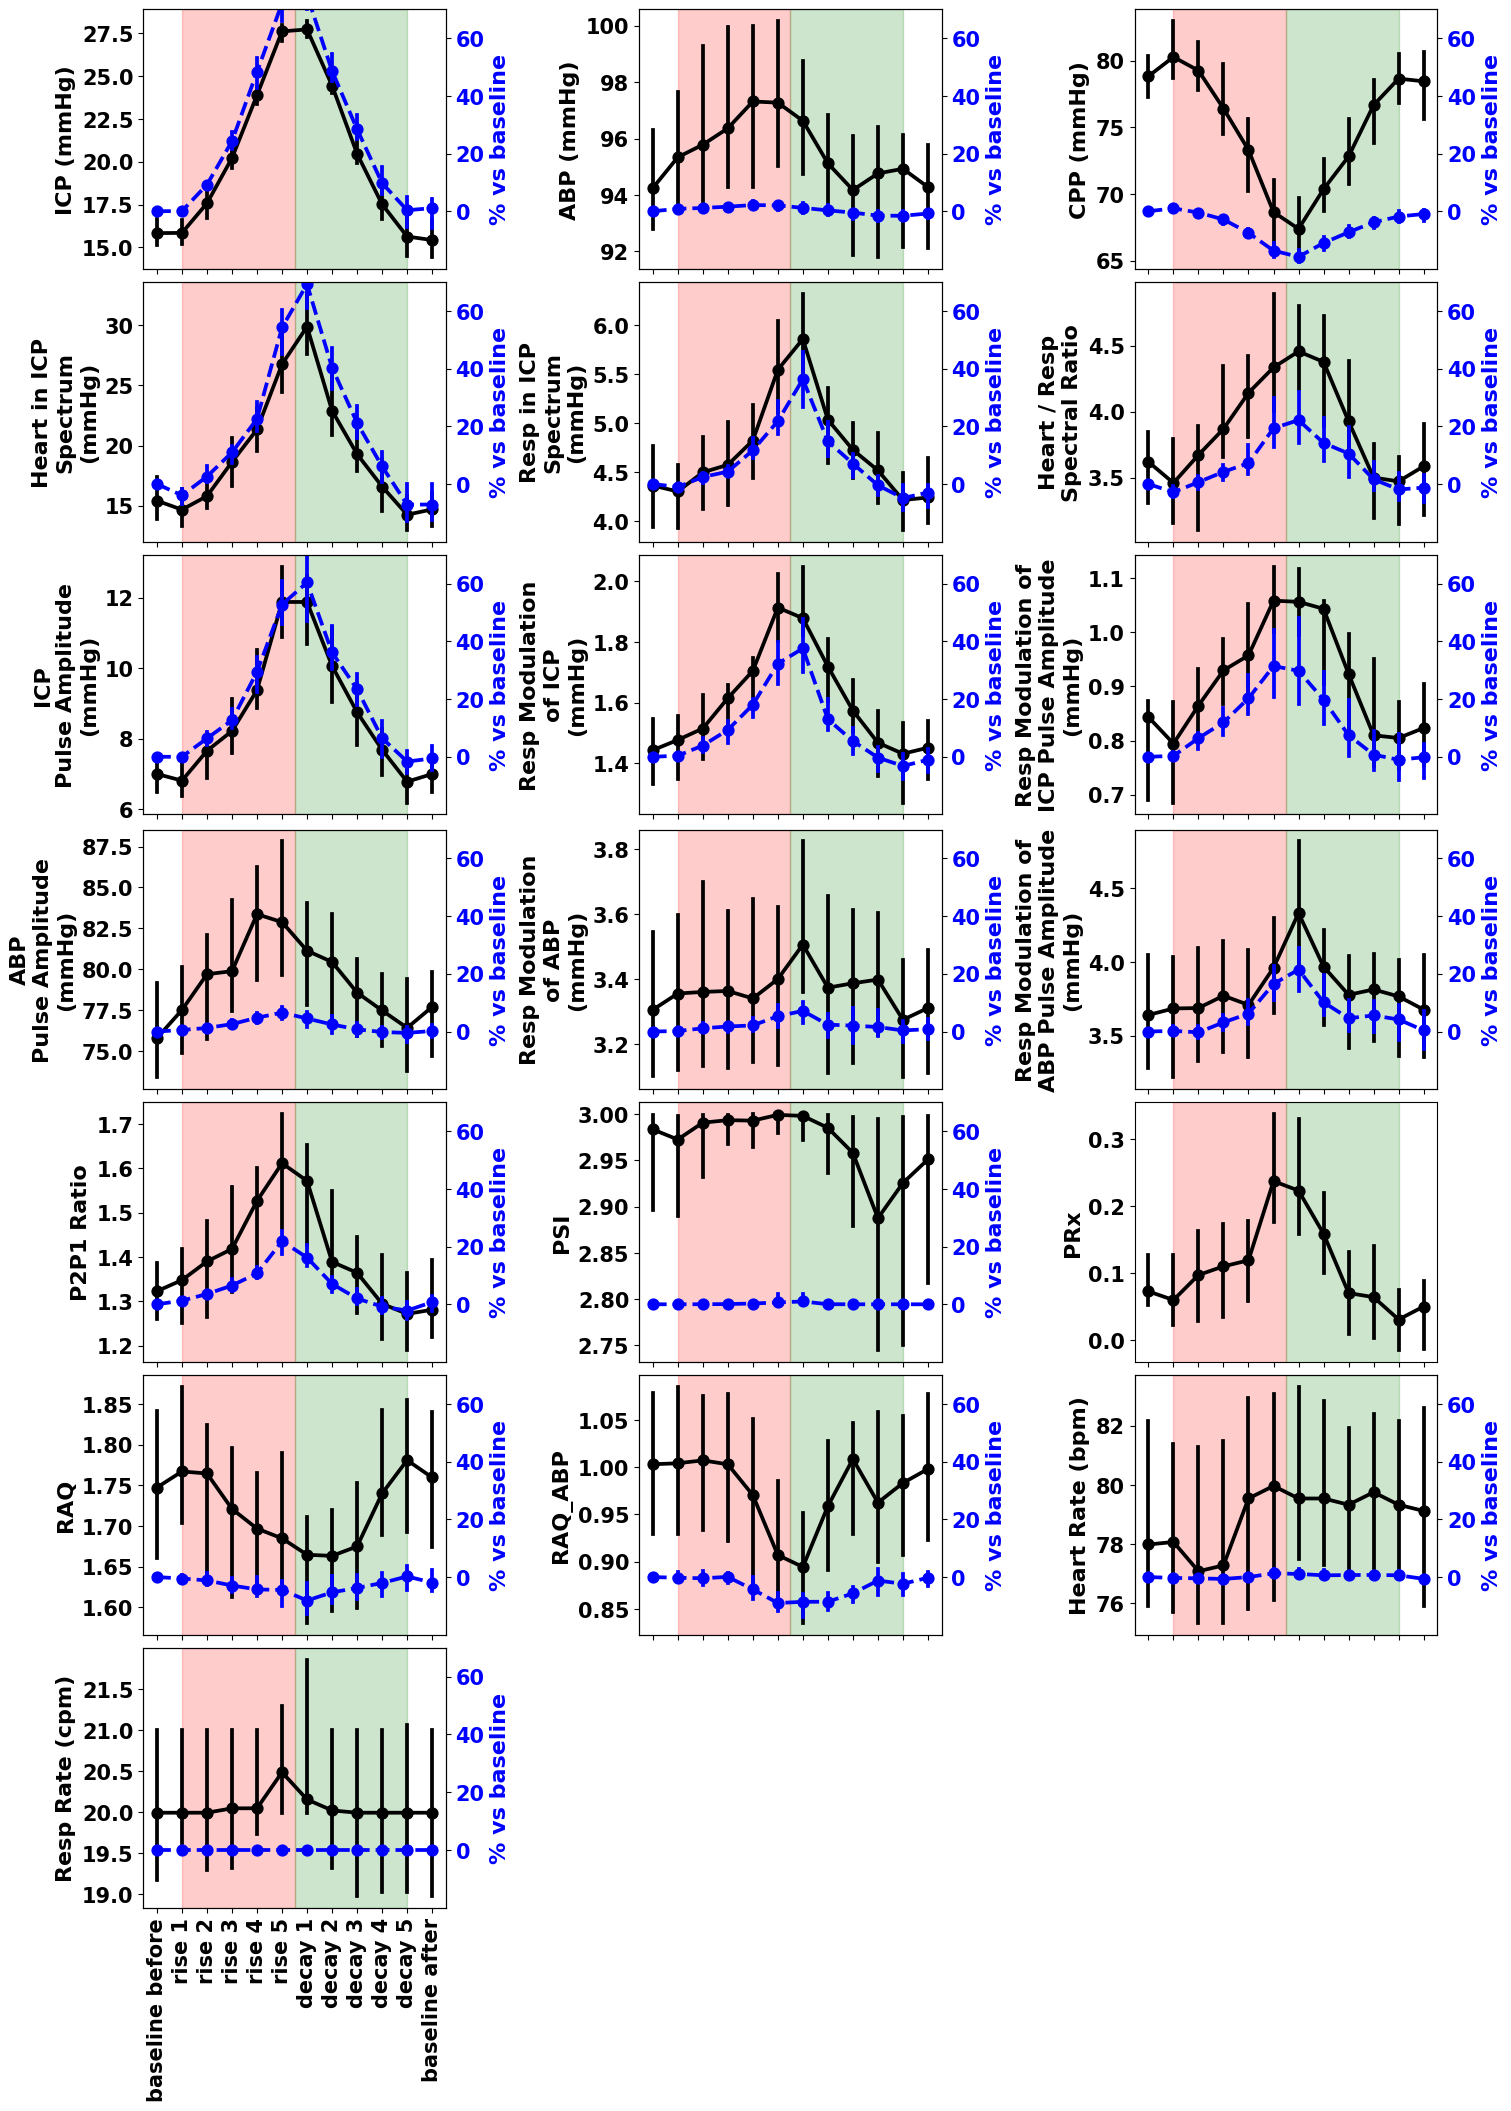

In [13]:
estimator = 'median'
# estimator = 'mean'

# metrics = ['median_icp_mmHg','heart_in_icp_spectrum','icp_pulse_amplitude_mmHg',
#            'resp_in_icp_spectrum','icp_resp_modulated','ratio_heart_resp_in_icp_spectrum', 
#            'icp_pulse_resp_modulated','median_abp_mmHg','median_cpp_mmHg',
#            'abp_pulse_amplitude_mmHg','abp_pulse_resp_modulated','abp_resp_modulated',
#            'RAQ_2','RAQ_ABP','P2P1_ratio', 
#            'PSI','PRx','heart_rate_bpm',
#            'resp_rate_cpm'
#            ]

metrics = ['median_icp_mmHg','median_abp_mmHg','median_cpp_mmHg',
           'heart_in_icp_spectrum','resp_in_icp_spectrum','ratio_heart_resp_in_icp_spectrum',
           'icp_pulse_amplitude_mmHg','icp_resp_modulated','icp_pulse_resp_modulated',
           'abp_pulse_amplitude_mmHg','abp_resp_modulated','abp_pulse_resp_modulated',
           'P2P1_ratio','PSI','PRx',
           'RAQ_2','RAQ_ABP','heart_rate_bpm',
           'resp_rate_cpm'
           ]

letters = get_plot_letters()[:len(metrics)]
d_letters = {m:l for m,l in zip(metrics, letters)}

nrows = 7
ncols = 3
poss = attribute_subplots(metrics, nrows, ncols)

fig, axs = plt.subplots(nrows, ncols, figsize = (ncols * 5,nrows * 3.), constrained_layout = True, sharex = True)
# fig.suptitle(f'Estimator : {estimator}')

for m, (r,c) in poss.items():
        ax = axs[r,c]  

        if m != 'PRx':
                ax2 = ax.twinx()
                sns.pointplot(data = res_norm,
                                x = 'win_label',
                                y = m,
                                ax=ax2,
                                errorbar=('ci',95),
                                estimator=estimator,
                                color = 'b',
                                linestyles="--",
                                )
                ax2.set_ylim(-20, 70)
                ax2.set_xticks(ax2.get_xticks(), ax2.get_xticklabels(), rotation = 90, **p_ticks)
                ax2.set_yticks(ax2.get_yticks()[1:-1], ax2.get_yticklabels()[1:-1], rotation = 0, **p_ticks | {'color':color_ax2})
                ax2.set_xlabel('')
                ax2.set_xticks(ax2.get_xticks(), [n.replace('_',' ') for n in compliance_all['win_label'].unique()], **p_ticks)
                ax2.set_ylabel('% vs baseline', **p_labels | {'color':color_ax2})


        sns.pointplot(data = compliance_all,
                        x = 'win_label',
                        y = m,
                        ax=ax,
                        errorbar=('ci',95),
                        estimator=estimator,
                        color = 'k',
                        )
        
        ax.set_yticks(ax.get_yticks()[1:-1], ax.get_yticklabels()[1:-1], rotation = 0, **p_ticks)
        ax.set_xlabel('')
        ax.set_xticks(ax.get_xticks(), [n.replace('_',' ') for n in compliance_all['win_label'].unique()], rotation = 90, **p_ticks)
        ax.set_ylabel(mapper_clean_name[m], **p_labels)
        letter = d_letters[m]
        ax.axvspan(1, 5.5, color = 'r', alpha = 0.2)
        ax.axvspan(5.5, 10, color = 'g', alpha = 0.2)

        # ylim = ax.get_ylim()
        # y_signif_line = min(ylim) + 0.05 * (max(ylim) - min(ylim))
        # ax.plot(np.arange(compliance_all['win_label'].unique().size), get_inds_signifs(m) * y_signif_line, **p_pval_line)

        # ax.text(x_letter, y_letter, letter, transform=ax.transAxes, **p_letter)
        # ax.set_title('Frequency domain : Heart and Respiration in ICP', **p_titles)
        # ax.legend(loc = 'upper right', fontsize = 11, framealpha = 0.5)
fig.delaxes(axs[nrows-1, ncols-2])
fig.delaxes(axs[nrows-1, ncols-1])
# fig.savefig(save_folder / f'fig2_{estimator}{img_extension}', dpi = dpi, bbox_inches = 'tight')

if save:
        hash_ = joblib.hash(slow_icp_rise_detection_params)
        save_path = Path.cwd() / 'figs_sensitivy_analysis' / hash_
        if not os.path.exists(save_path):
                os.makedirs(save_path)
                with open(save_path / '__params__.json', mode='w') as f:
                        json.dump(slow_icp_rise_detection_params, f, indent=4)
        fig.savefig(save_path / 'fig2.png', dpi = dpi, bbox_inches = 'tight')

plt.show()

# P2P1 distrib

In [ ]:
concat_subs = new_names_subs_compliance
concat = [ratio_P1P2_job.get(s)['ratio_P1P2'].to_series().quantile([0.5,0.6,0.7,0.75]).values for s in concat_subs]
concat = np.concatenate(concat)



In [ ]:
fig, ax = plt.subplots()
ax.hist(concat, bins = 30, density = True, color = 'k')
ax.set_xlabel('P2/P1 ratio')
ax.set_ylabel('Density')
plt.show()

# sensitivity analysis slow ICP rises detection

In [ ]:
folder = Path("/mnt/data/NEURO_REA_MONITORAGE/precompute/slow_icp_detection_compliance_features/07f1d5c0e7d4b41150d168bb8f269500")
subs = [str(f).split('/')[-1].split('.')[0] for f in folder.iterdir()]
len(subs)

In [ ]:
meta = get_metadata().set_index('ID_pseudo')
meta.columns

In [ ]:
[meta.at[s,'ID_pseudo_old'] for s in subs]

In [ ]:
np.array([meta.at[s,'ID_pseudo_old'] for s in subs])

In [ ]:
np.array(subs)

In [ ]:
def detect_slow_icp_rises_sensitivity(raw_icp,
                            icp_filtered, 
                            icp_smoothed_for_trough,
                            times,
                          datetimes,
                          datetimes_raw,
                          datetimes_smoothed,
                          params_detection = {'min_rise_duration_min':15,'min_rise_amplitude_mmHg':5, 'min_peak_amplitude_mmHg':20,'max_peak_amplitude_raw_mmHg':80,'min_decay_amplitude_mmHg':2, 'max_trough_amplitude_smoothed_mmHg':20},
                          ):
    """
    Inputs:
    - raw_icp : np.array = the raw ICP signal
    - icp_filtered : np.array = the ICP filtered signal
    - icp_smoothed_for_trough : np.array = an ICP filtered signal that fit better to raw trace to filter for trough amplitude
    - srate : float or int = sampling rate of the filtered ICP signal
    - datetimes : np.datetime64 = datetime vector of the filtered ICP signal
    - datetimes_raw = : np.datetime64 = datetime vector of the raw ICP signal
    - datetimes_smoothed = : np.datetime64 = datetime vector of the smoothed ICP signal
    - params_detection : dict = dictionnary of parameters aiming to post-process the detection by applying a mask
    - verbose : bool = print the highcut frequency of the filter

    Outputs :
    - detection : pd.DataFrame = detections with events in rows and features in columns
    """
    firt_derivarive_sig = np.gradient(icp_filtered)
    detection = detect_cross(firt_derivarive_sig, thresh = 0)
    detection.columns = ['trough_ind','peak_ind']
    detection['next_trough_ind'] = np.append(detection.loc[1:,'trough_ind'].values, np.nan)
    detection = detection.dropna()
    detection = detection.astype(int)
    detection['trough_time_s'] = times[detection['trough_ind']]
    detection['peak_time_s'] = times[detection['peak_ind']]
    detection['next_trough_time_s'] = times[detection['next_trough_ind']]
    detection['trough_date'] = datetimes[detection['trough_ind']]
    detection['peak_date'] = datetimes[detection['peak_ind']]
    detection['next_trough_date'] = datetimes[detection['next_trough_ind']]
    detection['rise_duration_s'] = detection['peak_time_s'] - detection['trough_time_s']
    detection['rise_duration_min'] = detection['rise_duration_s'] / 60
    detection['decay_duration_s'] = detection['next_trough_time_s'] - detection['peak_time_s']
    detection['decay_duration_min'] = detection['decay_duration_s'] / 60
    detection['trough_amplitude_mmHg'] = icp_filtered[detection['trough_ind']]
    detection['peak_amplitude_mmHg'] = icp_filtered[detection['peak_ind']]
    detection['next_trough_amplitude_mmHg'] = icp_filtered[detection['next_trough_ind']]
    detection['rise_amplitude_mmHg'] = detection['peak_amplitude_mmHg'] - detection['trough_amplitude_mmHg']
    raw_peak_inds = np.searchsorted(datetimes_raw, detection['peak_date'].values)
    detection['peak_amplitude_raw_mmHg'] = raw_icp[raw_peak_inds]
    smoothed_trough_inds = np.searchsorted(datetimes_smoothed, detection['trough_date'].values)
    detection['trough_amplitude_smoothed_mmHg'] = icp_smoothed_for_trough[smoothed_trough_inds]
    detection['decay_amplitude_mmHg'] = detection['peak_amplitude_mmHg'] - detection['next_trough_amplitude_mmHg']
    params_detection = {k:v for k,v in params_detection.items() if not v is None}
    if len(params_detection) != 0:
        masking = pd.DataFrame(index = detection.index, columns = params_detection.keys(), dtype = bool)
        masking[:] = True
        for param_name, threshold in params_detection.items():
            metric_name = param_name[4:]
            if 'min' in param_name:
                masking.loc[:,param_name] = detection[metric_name] > threshold
            elif 'max' in param_name:
                masking.loc[:,param_name] = detection[metric_name] < threshold
        mask = masking.all(axis = 1)
        detection = detection[mask].reset_index(drop = True)
    return detection

def slow_icp_rise_detection_sensivity(sub, **p):
    cns_reader = CnsReader(data_path / sub)
    stream = cns_reader.streams['ICP']
    raw_icp, datetimes_raw = stream.get_data(apply_gain = True, with_times = True)
    icp_filtered = icp_filter_for_detection_job.get(sub)['icp_filter_for_detection']
    icp_smoothed_for_trough = icp_filter_for_trough_filtering_job.get(sub)['icp_filter_for_trough_filtering']
    datetimes = icp_filtered['datetime'].values
    times = icp_filtered.attrs['time']
    datetimes_smoothed = icp_smoothed_for_trough['datetime'].values
    icp_filtered = icp_filtered.values
    params_detection = p
    detections = detect_slow_icp_rises_sensitivity(raw_icp, icp_filtered, icp_smoothed_for_trough, times, datetimes, datetimes_raw, datetimes_smoothed, params_detection=params_detection)
    # for col in detections.columns:
    #     if 'date' in col:
    #         detections[col] = detections[col].astype('datetime64[ns]')
    # if detections.shape[0] == 0:
    #     print(f'Warning : No event detected in sub {sub}')
    return detections.shape[0]

In [ ]:
sub = subs[0]

initial_params = {'min_rise_duration_min':15,
                'min_rise_amplitude_mmHg':5, 
                'min_peak_amplitude_mmHg':20,
                'max_peak_amplitude_raw_mmHg':80,
                'min_decay_amplitude_mmHg':2,
                'max_trough_amplitude_smoothed_mmHg':20
}


# test = slow_icp_rise_detection(sub, **slow_icp_rise_detection_params)

In [ ]:
# min_rise_duration_mins = [5,10,15,20,25]
# min_rise_amplitude_mmHgs = [3,5,7,10]
# min_peak_amplitude_mmHgs = [10,15,20,25,30]


compute_subs = subs[:10]
min_rise_duration_mins = [10,20,30,60,90]
min_rise_amplitude_mmHgs = [3,5,10,20]
min_peak_amplitude_mmHgs = [15,20,25,30]

total_iterations = len(compute_subs) * len(min_rise_duration_mins) * len(min_rise_amplitude_mmHgs) * len(min_peak_amplitude_mmHgs)

counter = 0

rows = []

for s in compute_subs:
    print(s)
    for min_rise_duration_min in min_rise_duration_mins:
        for min_rise_amplitude_mmHg in min_rise_amplitude_mmHgs:
            for min_peak_amplitude_mmHg in min_peak_amplitude_mmHgs:
                new_params = initial_params.copy()
                new_params['min_rise_duration_min'] = min_rise_duration_min
                new_params['min_rise_amplitude_mmHg'] = min_rise_amplitude_mmHg
                new_params['min_peak_amplitude_mmHg'] = min_peak_amplitude_mmHg
                N = slow_icp_rise_detection_sensivity(s, **new_params)
                row = dict(sub=s, min_rise_duration_min=min_rise_duration_min, min_rise_amplitude_mmHg=min_rise_amplitude_mmHg, min_peak_amplitude_mmHg=min_peak_amplitude_mmHg, N=N)
                rows.append(row)

                counter += 1
                if counter % 10 == 0:
                    print(counter, '/', total_iterations)

sensitivity = pd.DataFrame(rows)

In [ ]:
sensitivity

In [ ]:
# sensitivity.to_excel('sensitivity_slow_icp_rises.xlsx')
sensitivity = pd.read_excel('sensitivity_slow_icp_rises.xlsx')
sensitivity

In [ ]:
coords = dict(sub = sensitivity['sub'].unique(),
              min_rise_duration_min = sensitivity['min_rise_duration_min'].unique(),
              min_rise_amplitude_mmHg = sensitivity['min_rise_amplitude_mmHg'].unique(),
              min_peak_amplitude_mmHg = sensitivity['min_peak_amplitude_mmHg'].unique(),
             )
da = xr.DataArray(dims = coords.keys(), coords=coords)
for s in sensitivity['sub'].unique():
    for rise_dur in sensitivity['min_rise_duration_min'].unique():
        for rise_amp in sensitivity['min_rise_amplitude_mmHg'].unique():
            for peak_amp in sensitivity['min_peak_amplitude_mmHg'].unique():
                da.loc[s,rise_dur,rise_amp,peak_amp] = sensitivity.set_index(['sub','min_rise_duration_min','min_rise_amplitude_mmHg','min_peak_amplitude_mmHg']).loc[(s,rise_dur,rise_amp,peak_amp),'N']

In [ ]:
n_fig = 0

for s in da['sub'].values:
    print(s)
    n_fig += 1
    ncols = len(sensitivity['min_rise_duration_min'].unique())
    fig, axs = plt.subplots(ncols = ncols, figsize = (ncols * 4,4))
    fig.suptitle(f'S{n_fig}')
    for rise_dur, ax in zip(sensitivity['min_rise_duration_min'].unique(),axs):
        ax.set_title(f'min_rise_duration_minutes : {rise_dur}')
        da_plot = da.loc[s, rise_dur]
        ax.pcolormesh(da_plot['min_rise_amplitude_mmHg'].astype(str), da_plot['min_peak_amplitude_mmHg'].astype(str), da_plot)
        ax.set_xlabel('min_rise_amplitude_mmHg')
        ax.set_ylabel('min_peak_amplitude_mmHg')
        ax.set_xticks(range(da_plot['min_rise_amplitude_mmHg'].size), da_plot['min_rise_amplitude_mmHg'].values)
        # ax.set_xticks(da_plot['min_rise_amplitude_mmHg'].values)
        ax.set_yticks(range(da_plot['min_peak_amplitude_mmHg'].size), da_plot['min_peak_amplitude_mmHg'].values)

        data = da_plot.values
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                color = 'white' if val < data.mean() else 'black'
                
                ax.text(j, i, f"{val:.0f}",
                        ha='center', va='center', color=color)
    plt.show()

In [ ]:
n_fig = 0

# for s in da['sub'].values:
print(s)
n_fig += 1
ncols = len(sensitivity['min_rise_duration_min'].unique())
fig, axs = plt.subplots(ncols = ncols, figsize = (ncols * 4,4))
# fig.suptitle(f'S{n_fig}')
for rise_dur, ax in zip(sensitivity['min_rise_duration_min'].unique(),axs):
    ax.set_title(f'min_rise_duration_minutes : {rise_dur}')
    da_plot = da.sum('sub').loc[rise_dur]
    ax.pcolormesh(da_plot['min_rise_amplitude_mmHg'].astype(str), da_plot['min_peak_amplitude_mmHg'].astype(str), da_plot)
    ax.set_xlabel('min_rise_amplitude_mmHg')
    ax.set_ylabel('min_peak_amplitude_mmHg')
    ax.set_xticks(range(da_plot['min_rise_amplitude_mmHg'].size), da_plot['min_rise_amplitude_mmHg'].values)
    # ax.set_xticks(da_plot['min_rise_amplitude_mmHg'].values)
    ax.set_yticks(range(da_plot['min_peak_amplitude_mmHg'].size), da_plot['min_peak_amplitude_mmHg'].values)

    data = da_plot.values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            color = 'white' if val < data.mean() else 'black'
            
            ax.text(j, i, f"{val:.0f}",
                    ha='center', va='center', color=color)
plt.show()

# b) Subgroup analysis: Do correlations different for: Etiology (SAH or TBI or other)? Time since injury? Baseline value of ICP


In [4]:
compliance_all = concat_slow_icp_features('compliance')

P0022 not loaded
P0038 not loaded
P0004 not loaded
P0031 not loaded
P0046 not loaded
P0006 not loaded
P0085 not loaded
P0074 not loaded
P0075 not loaded
P0037 not loaded
P0065 not loaded
P0041 not loaded
P0015 not loaded


In [6]:
data_full = compliance_all.copy()
data_full

,patient,gender,age,stay_duration_days,diagnosis,glasgow_beginning,glasgow_end,mrs_end,fisher,wfns,...,P2P1_ratio,PSI,icp_pulse_amplitude_mmHg,abp_pulse_amplitude_mmHg,PRx,median_icp_mmHg,median_abp_mmHg,median_cpp_mmHg,heart_rate_bpm,resp_rate_cpm
0,P0051,F,50.745205,16.563194,HSA,3.0,11.0,5.0,NaN,NaN,...,1.576103,3.994943,15.1250,56.68750,NaN,13.864040,NaN,NaN,52.331682,15.682535
1,P0051,F,50.745205,16.563194,HSA,3.0,11.0,5.0,NaN,NaN,...,1.496443,3.986422,17.0000,57.12500,NaN,13.826450,NaN,NaN,46.562233,12.880158
2,P0051,F,50.745205,16.563194,HSA,3.0,11.0,5.0,NaN,NaN,...,1.611473,3.999214,18.7500,61.56250,NaN,15.960435,NaN,NaN,47.521478,12.858065
3,P0051,F,50.745205,16.563194,HSA,3.0,11.0,5.0,NaN,NaN,...,1.584382,3.999236,18.8750,63.06250,NaN,17.450580,NaN,NaN,50.143913,12.546037
4,P0051,F,50.745205,16.563194,HSA,3.0,11.0,5.0,NaN,NaN,...,1.651607,3.995603,19.6250,50.62500,NaN,21.751890,NaN,NaN,54.028938,12.051852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6211,P0021,M,48.600000,3.007639,HSA,3.0,14.0,5.0,NaN,NaN,...,1.032402,1.995274,6.7500,75.59375,0.109700,14.963382,92.957323,77.993941,NaN,NaN
6212,P0021,M,48.600000,3.007639,HSA,3.0,14.0,5.0,NaN,NaN,...,0.980374,1.885437,6.0000,60.87500,0.168697,9.509574,89.445925,79.936351,NaN,NaN
6213,P0021,M,48.600000,3.007639,HSA,3.0,14.0,5.0,NaN,NaN,...,1.083300,1.979672,6.1875,72.46875,0.549641,7.229072,87.352875,80.123803,NaN,NaN
6214,P0021,M,48.600000,3.007639,HSA,3.0,14.0,5.0,NaN,NaN,...,0.969085,1.870592,5.5000,51.75000,-0.459370,5.692384,81.673484,75.981101,NaN,NaN


In [8]:

mapper_clean_name = {
    "median_icp_mmHg" : "ICP (mmHg)",
    "heart_in_icp_spectrum" : "Heart\nin ICP Spectrum\n(mmHg)",
    "icp_pulse_amplitude_mmHg" : "ICP\nPulse Amplitude\n(mmHg)",
    "resp_in_icp_spectrum" : "Respiration\nin ICP Spectrum\n(mmHg)",
    "icp_resp_modulated" : "Respiratory\nModulation of ICP\n(mmHg)",
    "ratio_heart_resp_in_icp_spectrum" : "Heart / Resp\nSpectral Ratio",
    "icp_pulse_resp_modulated" : "Respiratory\nModulation of\nICP Pulse Amplitude (mmHg)",
    "median_abp_mmHg" : "ABP (mmHg)",
    "median_cpp_mmHg" : "CPP (mmHg)",
    "abp_pulse_amplitude_mmHg" : "ABP\nPulse Amplitude (mmHg)",
    "abp_pulse_resp_modulated" : "Respiratory\nModulation of\nABP Pulse Amplitude (mmHg)",
    "abp_resp_modulated" : "Respiratory\nModulation\nof ABP (mmHg)",
    "RAQ_2" : "RAQ_2",
    "RAQ_ABP" : "RAQ_ABP",
    "P2P1_ratio" : "P2P1 Ratio",
    "PSI" : "PSI",
    "PRx" : "PRx",
    "heart_rate_bpm" : "Heart Rate (bpm)",
    "resp_rate_cpm" : "Respiratory Rate (cpm)"
}


In [9]:
# data = data_full.iloc[:,45:51]
# full_metrics =  list(mapper_clean_name.keys())[:]
full_metrics = ['median_icp_mmHg','median_abp_mmHg','median_cpp_mmHg',
           'heart_in_icp_spectrum','resp_in_icp_spectrum','ratio_heart_resp_in_icp_spectrum',
           'icp_pulse_amplitude_mmHg','icp_resp_modulated','icp_pulse_resp_modulated',
           'abp_pulse_amplitude_mmHg','abp_resp_modulated','abp_pulse_resp_modulated',
           'P2P1_ratio','PSI','PRx',
           'RAQ_2','RAQ_ABP','heart_rate_bpm',
           'resp_rate_cpm'
           ]
data = data_full.loc[:,full_metrics]
print(data.columns)

Index(['median_icp_mmHg', 'median_abp_mmHg', 'median_cpp_mmHg',
       'heart_in_icp_spectrum', 'resp_in_icp_spectrum',
       'ratio_heart_resp_in_icp_spectrum', 'icp_pulse_amplitude_mmHg',
       'icp_resp_modulated', 'icp_pulse_resp_modulated',
       'abp_pulse_amplitude_mmHg', 'abp_resp_modulated',
       'abp_pulse_resp_modulated', 'P2P1_ratio', 'PSI', 'PRx', 'RAQ_2',
       'RAQ_ABP', 'heart_rate_bpm', 'resp_rate_cpm'],
      dtype='object')


In [ ]:
def compute_bins(series, nbins = 50, n_mads = 6):
    a = series.values
    max_ = np.nanmax(a)
    min_ = np.nanmin(a)
    name = series.name
    if np.any(np.isnan(a)):
        a = a[~np.isnan(a)]
    med, mad = physio.compute_median_mad(a)
    inf = med - n_mads * mad
    sup = med + n_mads * mad
    if sup > max_:
        sup = max_
    if inf < min_:
        inf = min_
    if name != 'PRx':
        bins = np.linspace(inf if inf > 0 else 0, sup, nbins)
    else:
        bins = np.linspace(inf, sup, nbins)
    return bins

In [ ]:
def get_significance(p_value):
    if p_value <= 0.001:
        return "***"
    elif p_value <= 0.01:
        return "**"
    elif p_value <= 0.05:
        return "*"
    else:
        return "ns"

In [14]:
def pairplot_homemade(data, mapper_clean_name = None, savefile = None, **kwargs):
    p_labels = kwargs.get("p_labels", {})  # Extract p_labels if provided
    p_ticks = kwargs.get("p_ticks", {})  # Extract p_ticks if provided
    metrics = data.columns.tolist()
    if mapper_clean_name is None:
        mapper_clean_name = {k:v for k,v in zip(metrics,metrics)}
    combinations = [i for i in itertools.combinations(metrics, 2)]

    nrows = len(data.columns)
    ncols = nrows

    norm = Normalize(-1, 1)
    cmap = plt.get_cmap('seismic')

    figsize = (nrows * 3, ncols * 3)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize = figsize, constrained_layout = True)

    is_done = pd.DataFrame(index = data.columns, columns = data.columns, dtype = 'bool')
    is_done[:] = False
    for r in range(nrows):
        for c in range(ncols):
            ax = axs[r,c]
            row_metric = data.columns[r]
            col_metric = data.columns[c]
            if row_metric == col_metric and not is_done.iloc[r,c]:
                bins_x = compute_bins(data[row_metric])
                ax.hist(data[row_metric], bins=bins_x, color = 'k')
                ax.set_xlabel(mapper_clean_name[row_metric], **p_labels)
                ax.set_ylabel('Count', **p_labels)
                ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), **p_ticks)
                ax.set_yticks(ax.get_yticks(), ax.get_yticklabels(), **p_ticks)
            else:
                if not is_done.iloc[r,c] and not is_done.iloc[c,r]: 
                    bins_x = compute_bins(data[row_metric])
                    bins_y = compute_bins(data[col_metric])
                    sns.histplot(data = data, x = row_metric, y = col_metric, ax = ax, bins = (bins_x,bins_y), color = 'k', pthresh=0.05, pmax=0.95)
                    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), **p_ticks)
                    ax.set_yticks(ax.get_yticks(), ax.get_yticklabels(), **p_ticks)
                else:
                    data_sel = data[[row_metric, col_metric]].dropna()
                    res = scipy.stats.spearmanr(data_sel[row_metric], data_sel[col_metric])
                    r_coef = res.statistic
                    p = res.pvalue * len(combinations)
                    p = 1 if p > 1 else p
                    s = 'R : {r_coef}\np : {p}'.format(r_coef=round(r_coef, 3), p = get_significance(p))
                    ax.text(0.5, 0.5, s, ha = 'center', weight = 'bold', fontsize = 20, va = 'center')
                    ax.set_facecolor(cmap(norm(r_coef)))
                    ax.set_xticks([])
                    ax.set_yticks([])
                ax.set_xlabel(mapper_clean_name[row_metric], **p_labels)
                ax.set_ylabel(mapper_clean_name[col_metric], **p_labels)
            is_done.iloc[r,c] = True
    if not savefile is None:
        fig.savefig(savefile, bbox_inches = 'tight', dpi = 500)
    plt.show()

28


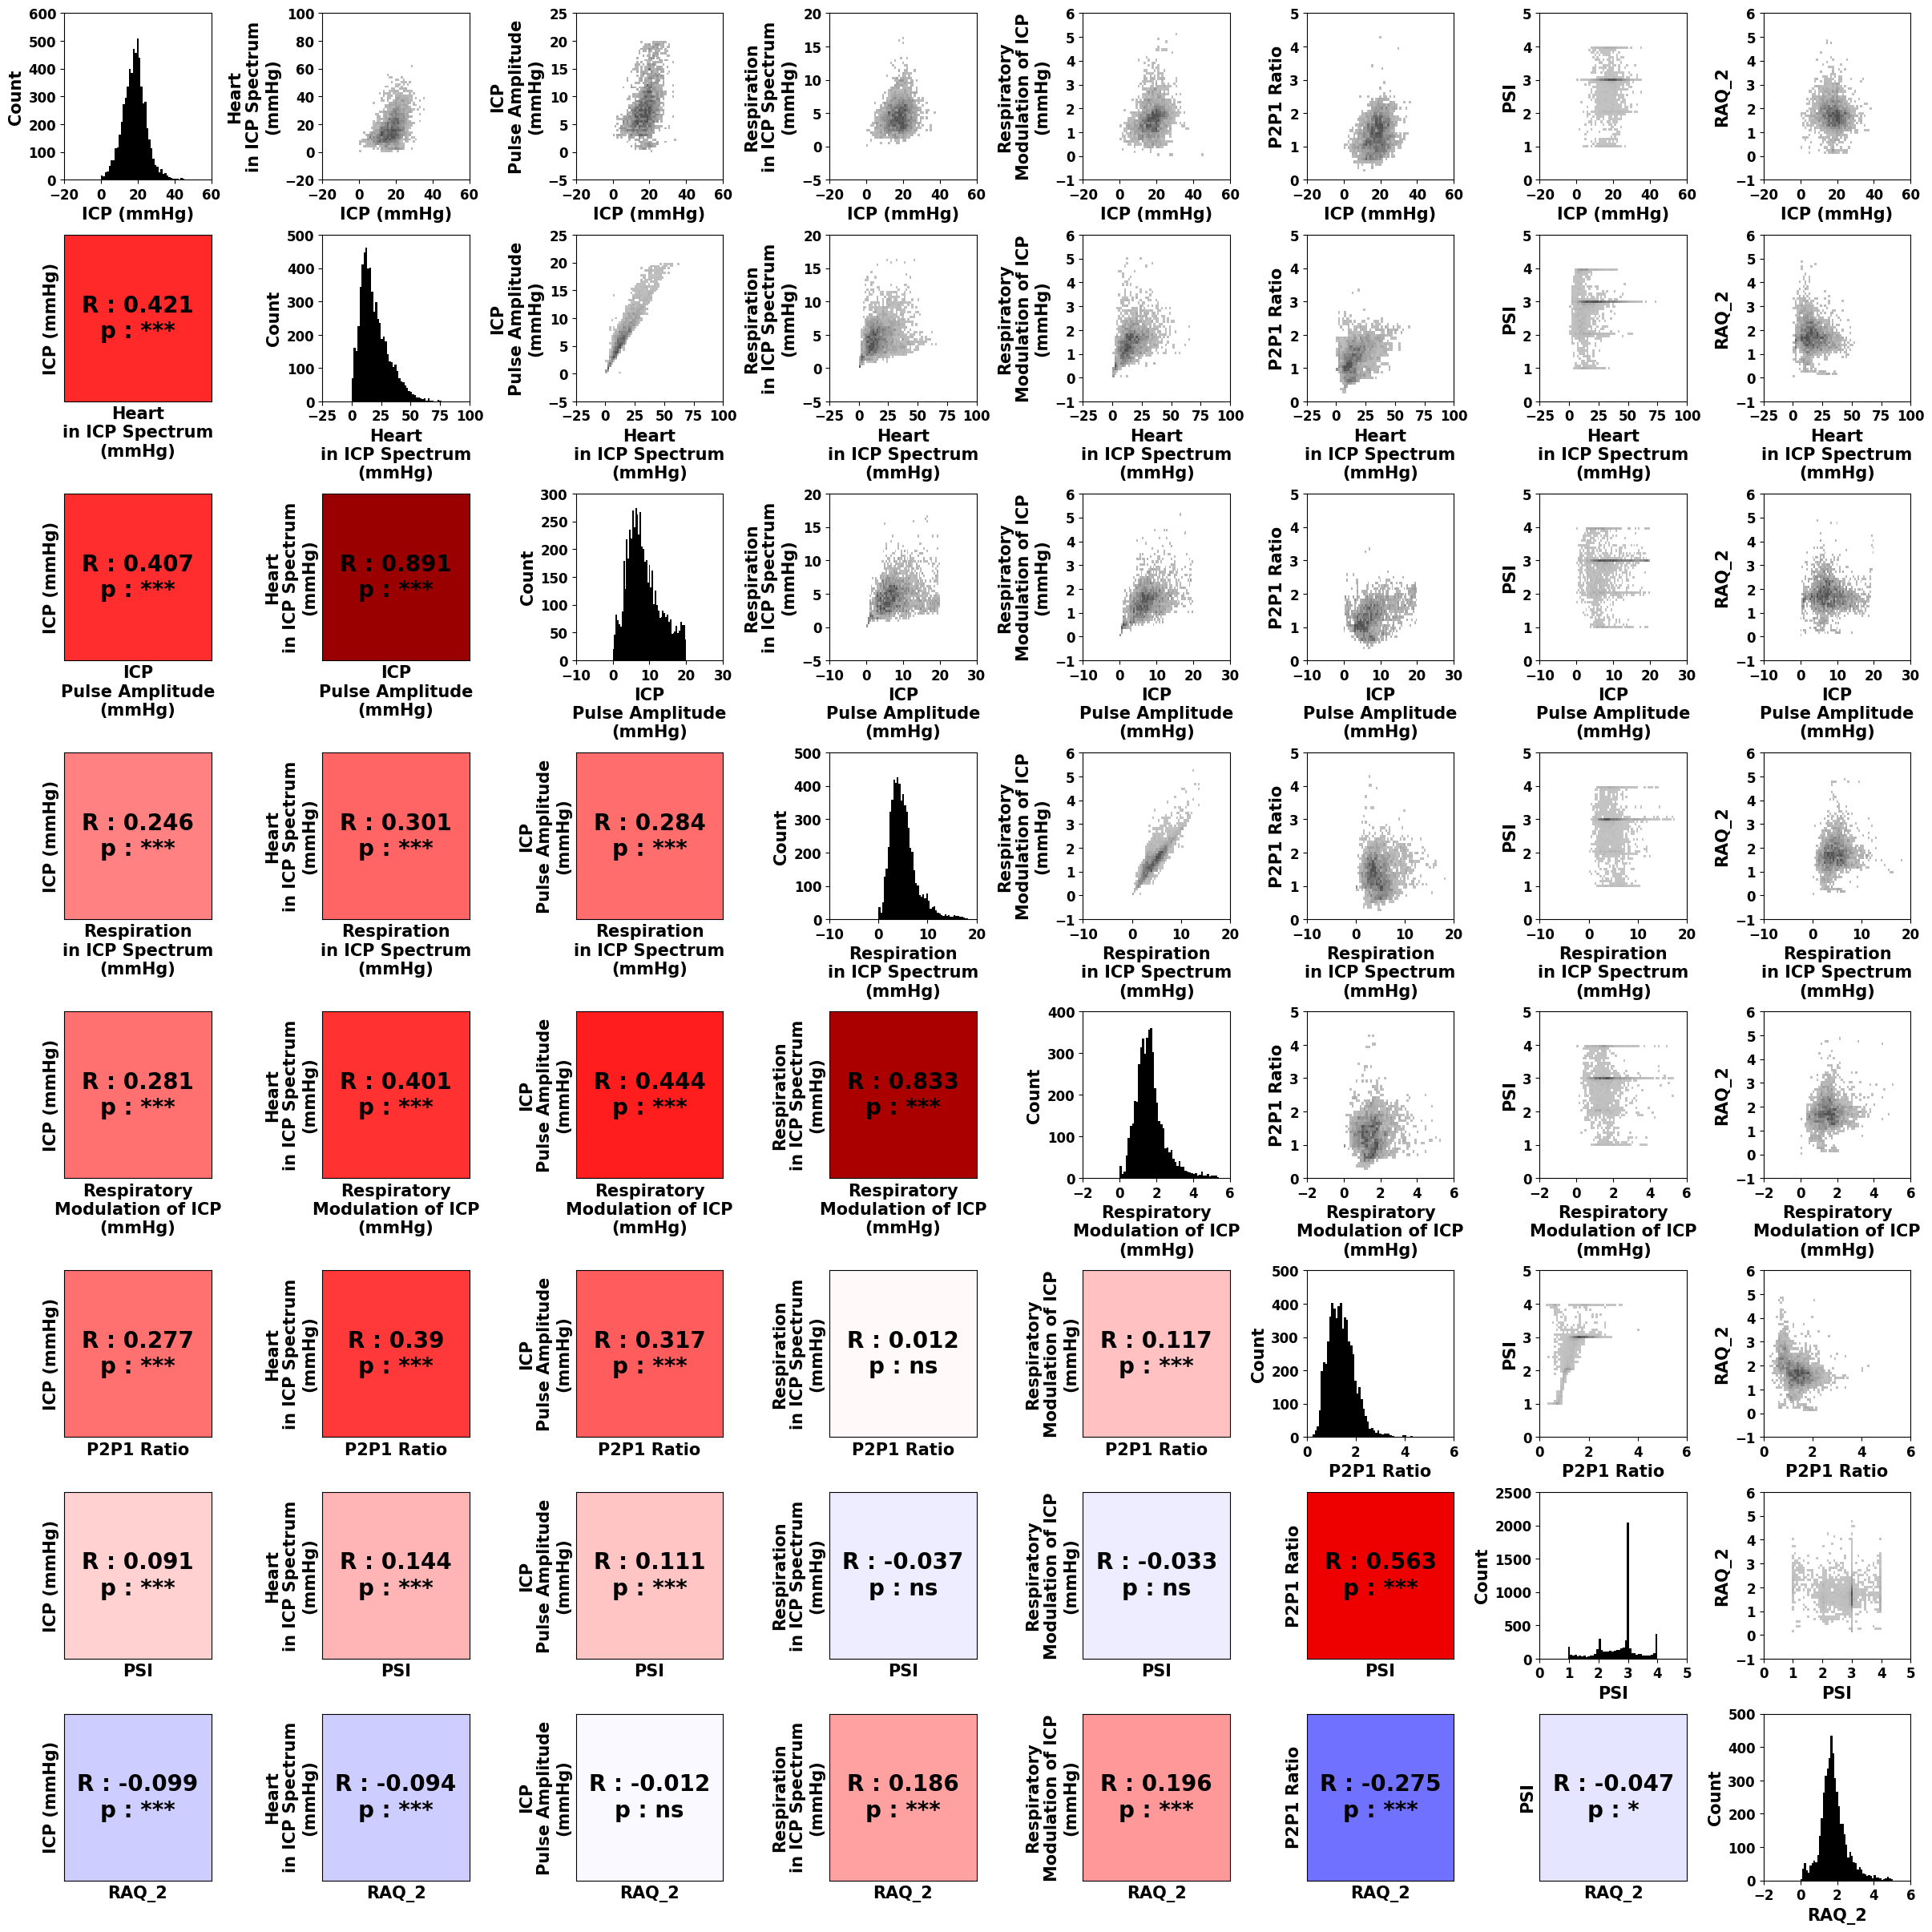

In [15]:
metrics = ['median_icp_mmHg',
 'heart_in_icp_spectrum',
 'icp_pulse_amplitude_mmHg',
 'resp_in_icp_spectrum',
 'icp_resp_modulated',
 'P2P1_ratio',
 'PSI',
 'RAQ_2',
 ]

# metrics = ['median_icp_mmHg',
#  'heart_in_icp_spectrum',
#  'icp_pulse_amplitude_mmHg',
#  'resp_in_icp_spectrum',
#  ]

print(len([i for i in itertools.combinations(metrics, 2)]))

p_labels = dict(
    fontsize = 15,
    weight = 'bold'
)
p_ticks = dict(
    weight = 'bold',
    fontsize = 12
)
# pairplot_homemade(data_full[metrics], mapper_clean_name, savefile = save_folder / 'short_pairplot.png', p_labels=p_labels, p_ticks=p_ticks)
pairplot_homemade(data_full[metrics], mapper_clean_name, p_labels=p_labels, p_ticks=p_ticks)
# pairplot_homemade(data_full[metrics], mapper_clean_name, savefile = None, p_labels=p_labels, p_ticks=p_ticks)

Text(0.5, 1.0, 'Difference of correlations coefficients : SAH minus TBI ')

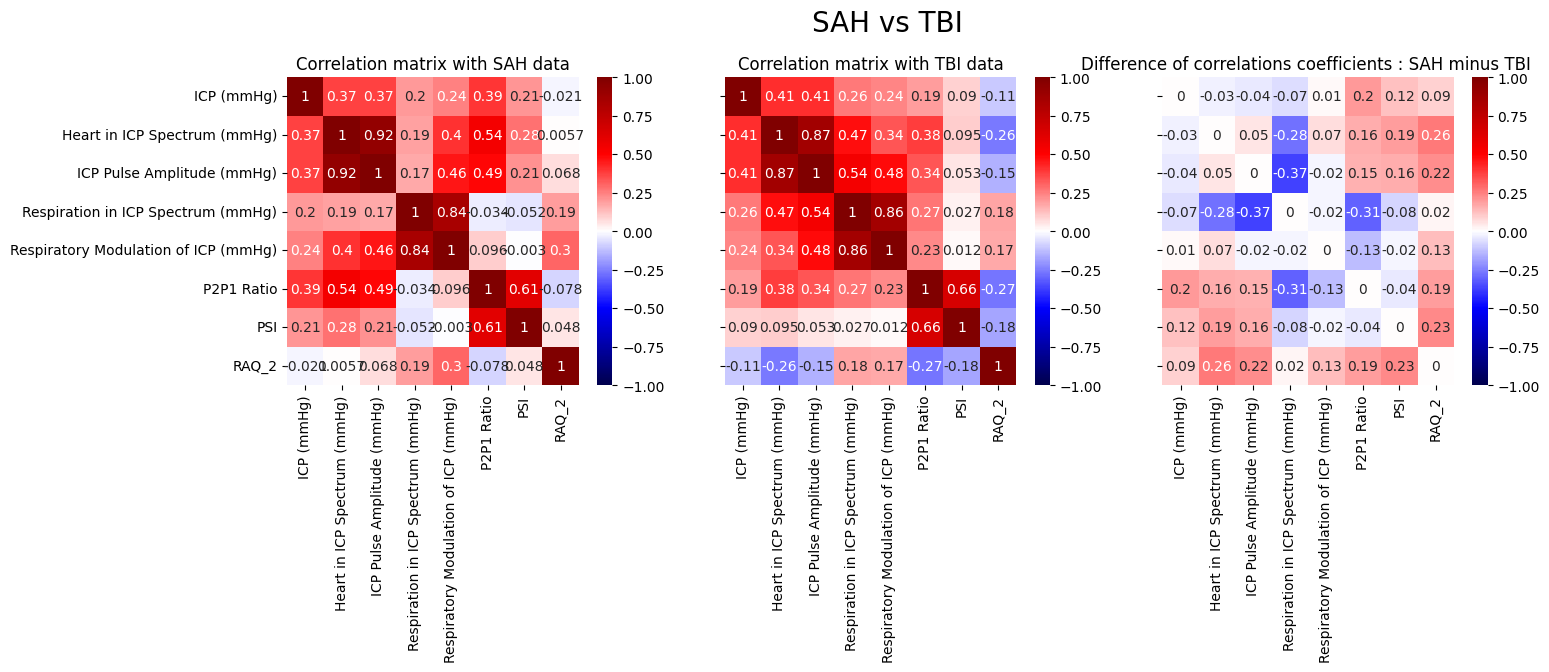

In [74]:
data_sah = data_full[data_full['diagnosis'] == 'HSA']
data_tbi = data_full[data_full['diagnosis'] == 'TC']

fig, axs = plt.subplots(ncols = 3, figsize = (16,4), sharey = True)
fig.suptitle('SAH vs TBI', fontsize = 20, y = 1.05)

ax = axs[0]
m_sah = data_sah[metrics].corr('spearman')
m_sah.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_sah.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_sah, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with SAH data')

ax = axs[1]
m_tbi = data_tbi[metrics].corr('spearman')
m_tbi.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_tbi.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_tbi, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with TBI data')

ax = axs[2]
sah_minus_tbi = m_sah - m_tbi
sns.heatmap(sah_minus_tbi.round(2), annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Difference of correlations coefficients : SAH minus TBI ')

Text(0.5, 1.0, 'Difference of correlations coefficients : Early minus Late ')

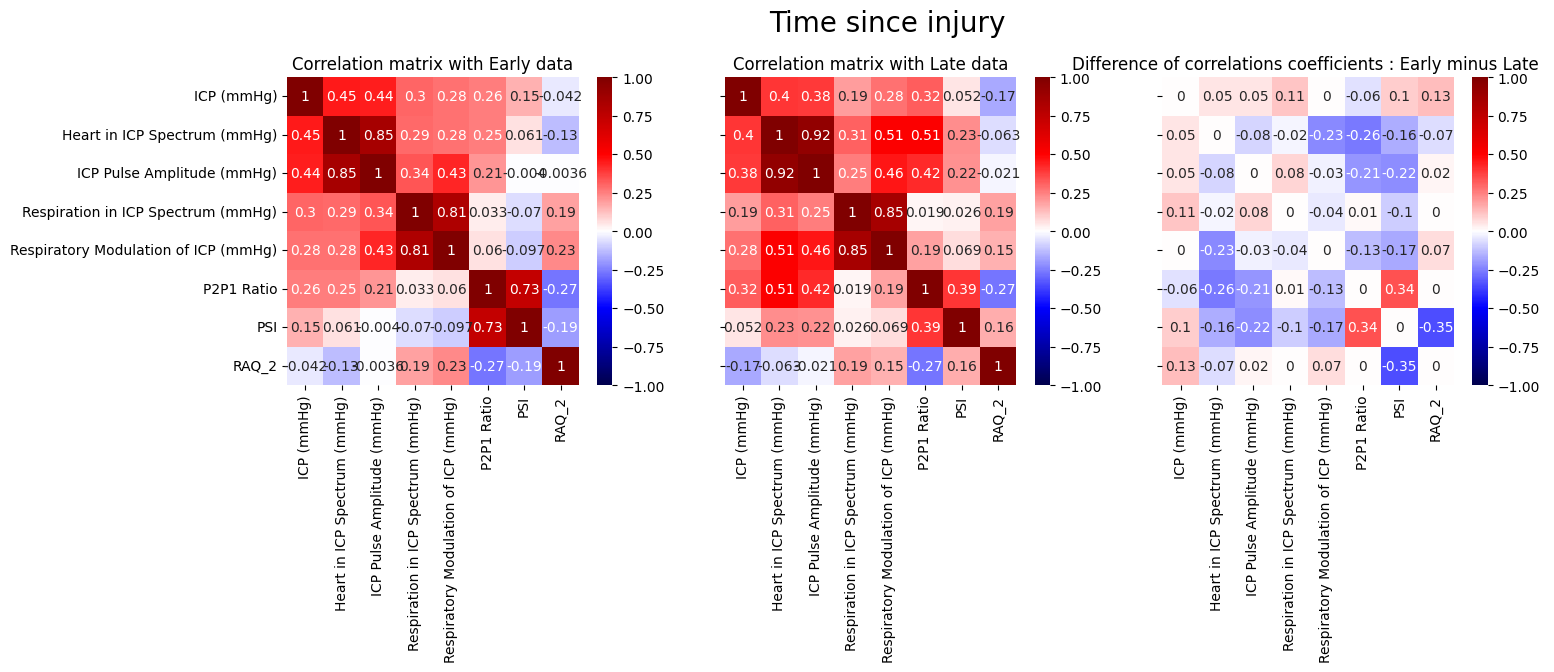

In [75]:
data_early = data_full[data_full['stay_duration_days'] < data_full['stay_duration_days'].median()]
data_late = data_full[data_full['stay_duration_days'] >= data_full['stay_duration_days'].median()]

fig, axs = plt.subplots(ncols = 3, figsize = (16,4), sharey = True)
fig.suptitle('Time since injury', fontsize = 20, y = 1.05)

ax = axs[0]
m_early = data_early[metrics].corr('spearman')
m_early.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_early.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_early, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with Early data')

ax = axs[1]
m_late = data_late[metrics].corr('spearman')
m_late.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_late.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_late, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with Late data')

ax = axs[2]
early_minus_late = m_early - m_late
sns.heatmap(early_minus_late.round(2), annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Difference of correlations coefficients : Early minus Late ')

Text(0.5, 1.0, 'Difference of correlations coefficients : High minus Low')

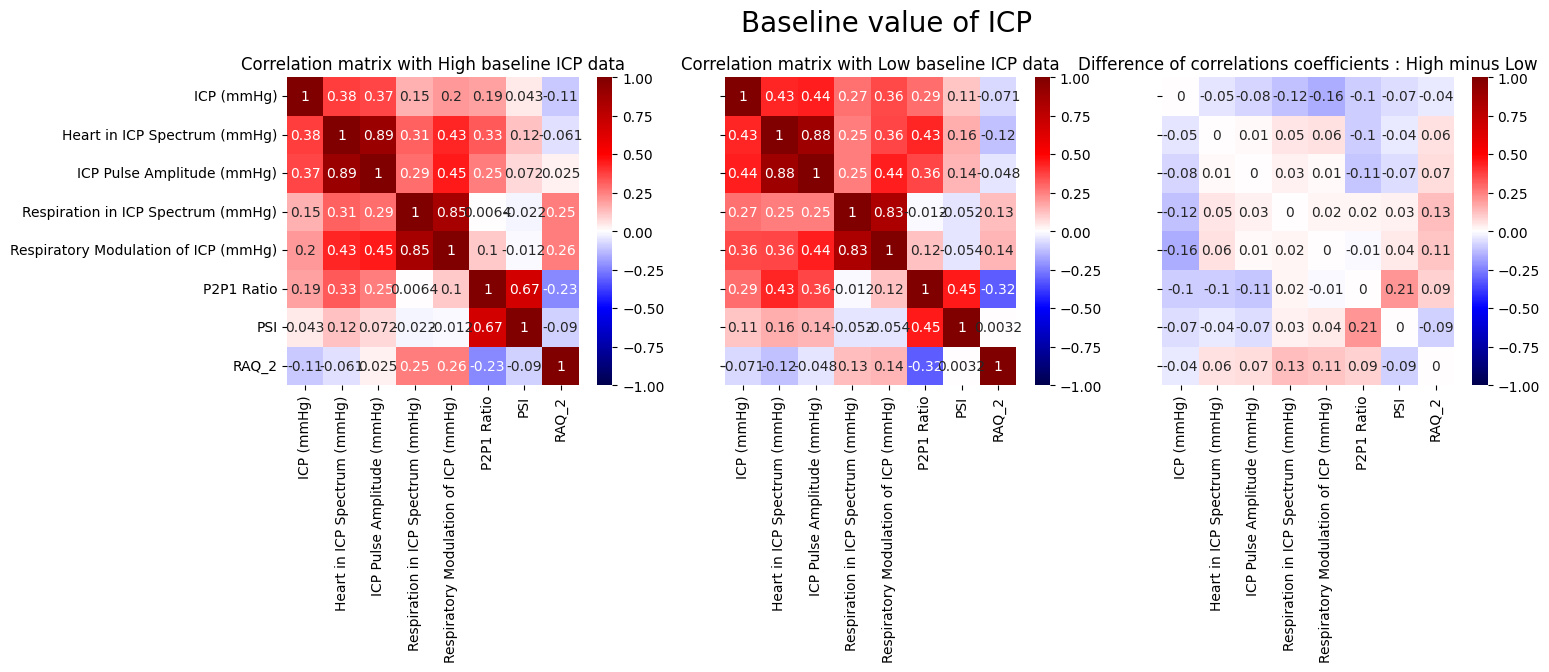

In [76]:
data_low_baseline_icp = data_full[data_full['trough_amplitude_mmHg'] < data_full['trough_amplitude_mmHg'].median()]
data_high_baseline_icp = data_full[data_full['trough_amplitude_mmHg'] >= data_full['trough_amplitude_mmHg'].median()]

fig, axs = plt.subplots(ncols = 3, figsize = (16,4), sharey = True)
fig.suptitle('Baseline value of ICP', fontsize = 20, y = 1.05)

ax = axs[0]
m_high = data_high_baseline_icp[metrics].corr('spearman')
m_high.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_high.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_high, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with High baseline ICP data')

ax = axs[1]
m_low = data_low_baseline_icp[metrics].corr('spearman')
m_low.index = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
m_low.columns = [mapper_clean_name[n].replace('\n',' ') for n in metrics]
sns.heatmap(m_low, annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Correlation matrix with Low baseline ICP data')

ax = axs[2]
high_minus_low = m_high - m_low
sns.heatmap(high_minus_low.round(2), annot = True, cmap = 'seismic', vmin = -1, vmax=1, ax=ax)
ax.set_title('Difference of correlations coefficients : High minus Low')